# Практические занятия: листки № 1 и № 2

Полное решение задач по линейной алгебре, матрицам, квадратичным формам и комплексным числам.  
Все вычислительные и графические пункты можно воспроизвести командой **Run All**.

In [1]:
import math
import cmath
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.special import gamma, loggamma

sp.init_printing()
plt.rcParams.update({'figure.figsize': (7, 5), 'axes.grid': True})
print('Среда готова:', 'NumPy', np.__version__, '| SymPy', sp.__version__)

Среда готова: NumPy 2.3.5 | SymPy 1.14.0


# Листок № 1. СЛАУ, матрицы, квадратичные формы

## 1.1. Общее решение СЛАУ

Свободная переменная $x_4=t$. Ответ:
$$x_1=-\frac{11}{7}-\frac{8t}{7},\quad x_2=-\frac67+\frac{2t}{7},\quad
x_3=\frac47+\frac{t}{7},\quad x_4=t.$$

In [2]:
A = sp.Matrix([[1,5,-2,0],[-3,1,9,-5],[4,-8,-1,7]])
b = sp.Matrix([-7,9,0])
sp.Matrix.hstack(A,b).rref()

⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

## 1.2. rref и общее решение

$$x=(4-2s-3t,\ 7-5s-6t,\ s,\ t,\ 8),\qquad s,t\in\mathbb R.$$

In [3]:
A = sp.Matrix([[5,-1,5,9,-2],[3,0,6,9,-1],[2,0,4,6,-1]])
b = sp.Matrix([-3,4,0])
sp.Matrix.hstack(A,b).rref()

⎛⎡1  0  2  3  0  4⎤           ⎞
⎜⎢                ⎥           ⎟
⎜⎢0  1  5  6  0  7⎥, (0, 1, 4)⎟
⎜⎢                ⎥           ⎟
⎝⎣0  0  0  0  1  8⎦           ⎠

## 1.3. Представление $y$ как функции от $x$

После исключения свободного параметра:
$$\boxed{y=14027-4262x},\qquad a=14027,\quad b=-4262.$$

In [4]:
x,y,z,u = sp.symbols('x y z u')
A = sp.Matrix([[32,97,90,48],[35,84,91,54],[17,18,21,13]])
b = sp.Matrix([47,40,37])
sol = sp.linsolve((A,b),(x,y,z,u))
sol

## 1.4. Действия с матрицами

In [5]:
L = sp.Matrix([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
M = sp.Matrix([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
N = sp.Matrix([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])
L*M + N

⎡7   4  5   11⎤
⎢             ⎥
⎢6   4  -1  6 ⎥
⎢             ⎥
⎢0   0  6   12⎥
⎢             ⎥
⎣-1  2  1   3 ⎦

## 1.5. Определители специального вида

Последовательное вычитание соседних строк/столбцов даёт:

- $\det[\min(i,j)]=1$;
- $\det[\max(i,j)]=(-1)^{n-1}n$;
- при $n\ge2$: $\det[|i-j|]=(-1)^{n-1}(n-1)2^{n-2}$; при $n=1$ определитель равен нулю.

## 1.6. Максимальный определитель шестого порядка

Максимум равен $160$. Ниже — достигающая его матрица.

In [6]:
M6 = sp.Matrix([
 [ 1, 1,-1,-1, 1,-1],
 [ 1, 1, 1,-1,-1, 1],
 [ 1,-1,-1, 1, 1, 1],
 [ 1, 1, 1, 1, 1,-1],
 [ 1,-1, 1,-1,-1,-1],
 [-1,-1, 1,-1, 1, 1],
])
M6.det()

## 1.7. Почти диагональная матрица, $n=80000$

In [7]:
n = 80000
d = np.linspace(.99, 1.01, n)
log_det = np.log(d[2:]).sum() + np.log(d[0]*d[1] - .57*.03)
det_A = np.exp(log_det)
trace_inv = (d[0]+d[1])/(d[0]*d[1]-.57*.03) + (1/d[2:]).sum()
det_A, trace_inv

## 1.8. Обратная верхнетреугольная матрица, $n=43000$

In [8]:
n = 43000
q = 1.07**(1/(n-1))
d = q**np.arange(n)
a = np.linspace(1, 1.10, n)
first_row_inverse = -a[1:]/d[1:]
minimum = first_row_inverse.min()
element_sum = 1 + np.sum((1-a[1:])/d[1:])
minimum, element_sum

## 1.9. Степени матрицы

In [9]:
g = .057
A = np.array([[7*g,14*g],[9*g,g]], float)
S_4_70 = sum(np.linalg.matrix_power(A,k) for k in range(4,71))
B_4 = np.linalg.inv(np.eye(2)-A) @ np.linalg.matrix_power(A,4)

def smallest_k():
    for k in range(1,300):
        if all(sum(np.linalg.matrix_power(A,j) for j in range(k,n+1)).max() < .0002
               for n in range(k+1,1000)):
            return k

S_4_70, B_4, smallest_k()

(array([[3.60967903, 3.43309957],
        [2.20699258, 2.13835065]]),
 array([[3.61117468, 3.43453189],
        [2.20791336, 2.13923244]]),
 89)

## 1.10. Определитель как многочлен

In [10]:
x = sp.symbols('x')
M = sp.Matrix([[7,5,5,x],[2,2,6,9],[3,x,8,0],[3,1,1,0]])
sp.expand(M.det())

## 1.11. Биномиальные коэффициенты по модулю 2

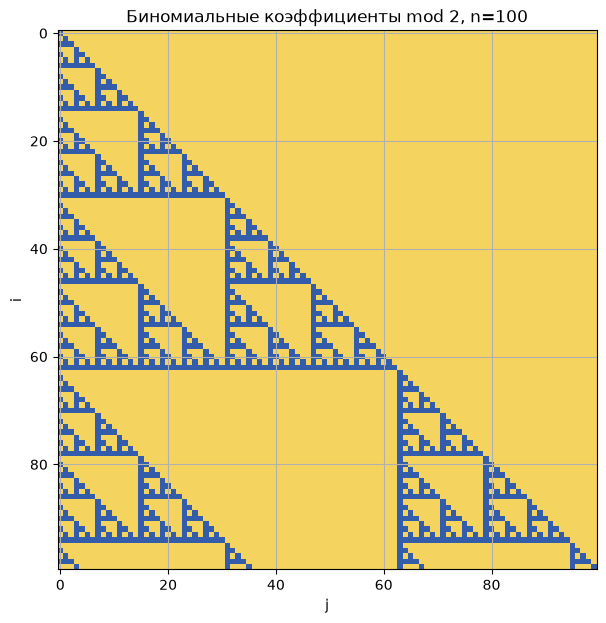

In [11]:
n = 100
P = np.zeros((n,n), int)
for i in range(1,n+1):
    for j in range(1,i+1):
        P[i-1,j-1] = math.comb(i,j) % 2
plt.figure(figsize=(7,7))
plt.imshow(P, cmap=ListedColormap(['#f4d35e','#335caa']), interpolation='nearest')
plt.title('Биномиальные коэффициенты mod 2, n=100')
plt.xlabel('j'); plt.ylabel('i'); plt.show()

## 1.12. Матрицы Адамара

$H_1=[1]$, $H_2=\begin{pmatrix}1&1\\1&-1\end{pmatrix}$, $H_4=H_2\otimes H_2$.
Рекурсия $H_{2^k}=H_2\otimes H_{2^{k-1}}$ сохраняет равенство
$H_{2^k}H_{2^k}^{T}=2^kI$.

Проверка: True


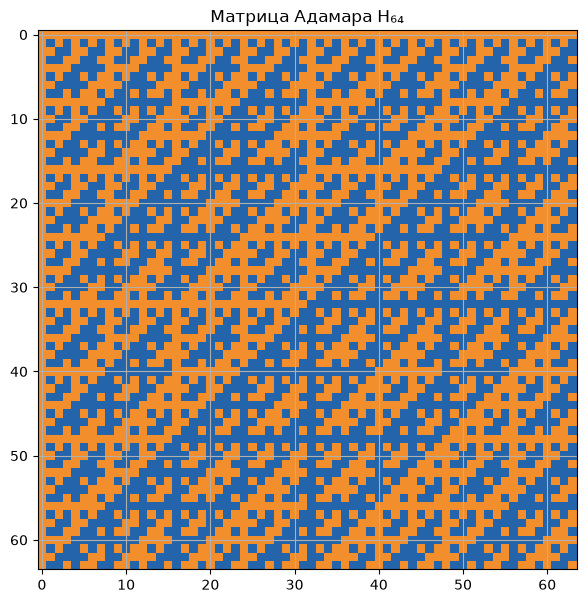

In [12]:
H = np.array([[1]], int)
for _ in range(6):
    H = np.block([[H,H],[H,-H]])
print('Проверка:', np.array_equal(H@H.T, 64*np.eye(64, dtype=int)))
plt.figure(figsize=(7,7))
plt.imshow(H, cmap=ListedColormap(['#2364aa','#f28e2b']), interpolation='nearest')
plt.title('Матрица Адамара H₆₄'); plt.show()

## 1.13. Собственное значение и собственный вектор

In [13]:
A = np.array([[14,10,21],[12,15,26],[18,11,27]], complex)
vals, vecs = np.linalg.eig(A)
j = np.argmax(vals.imag)
Z = vals[j]
X = vecs[:,j] / vecs[0,j]
print('Z =', Z)
print('X =', X)
print('Im Z =', Z.imag, '; Re U =', X[1].real)

Z = (1.96884033080165+0.344789348427175j)
X = [ 1.        +0.j          3.74781973+1.33084677j -2.35758843-0.61731802j]
Im Z = 0.344789348427175 ; Re U = 3.7478197293948092


## 1.14. Минимальный многочлен

In [14]:
A = sp.Matrix([
[-3,7,-6,-1,8,-3,-2],[1,-5,8,-3,-5,4,-5],[1,3,-4,6,-2,0,8],
[-1,11,-12,9,3,-3,9],[-3,11,-12,5,8,-4,6],[-3,2,1,-4,4,1,-7],
[1,-5,6,-2,-4,3,-2]])
print('χ(t) =', sp.factor(A.charpoly().as_expr()))
print('nullity A^k:', [7-(A**k).rank() for k in (1,2,3)])
print('nullity (A-I)^k:', [7-((A-sp.eye(7))**k).rank() for k in (1,2,3)])
print('m_A(t) = t^3(t-1)^2')

χ(t) = lambda**3*(lambda - 1)**4
nullity A^k: [1, 2, 3]
nullity (A-I)^k: [2, 4, 4]
m_A(t) = t^3(t-1)^2


## 1.15. Собственный ортонормированный базис

$$e_1=(1,1,0)/\sqrt2,\quad e_2=(1,-1,-4)/(3\sqrt2),\quad e_3=(2,-2,1)/3.$$
В этом базисе матрица равна $\operatorname{diag}(9,9,27)$.

In [15]:
A = sp.Matrix([[17,-8,4],[-8,17,-4],[4,-4,11]])
Q = sp.Matrix.hstack(sp.Matrix([1,1,0])/sp.sqrt(2),
                     sp.Matrix([1,-1,-4])/(3*sp.sqrt(2)),
                     sp.Matrix([2,-2,1])/3)
sp.simplify(Q.T*A*Q)

⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

## 1.16. Приведение к главным осям

Для ортогональной замены $x=Qy$ возьмём столбцы
$(2,1,0,0)/\sqrt5$, $(-1,2,0,0)/\sqrt5$, $(0,0,-2,1)/\sqrt5$, $(0,0,1,2)/\sqrt5$.
Тогда $f=5y_1^2-5y_2^2+5y_3^2$.

In [16]:
A = sp.Matrix([[3,4,0,0],[4,-3,0,0],[0,0,4,-2],[0,0,-2,1]])
Q = sp.Matrix.hstack(sp.Matrix([2,1,0,0])/sp.sqrt(5),
                     sp.Matrix([-1,2,0,0])/sp.sqrt(5),
                     sp.Matrix([0,0,-2,1])/sp.sqrt(5),
                     sp.Matrix([0,0,1,2])/sp.sqrt(5))
sp.simplify(Q.T*A*Q)

⎡5  0   0  0⎤
⎢           ⎥
⎢0  -5  0  0⎥
⎢           ⎥
⎢0  0   5  0⎥
⎢           ⎥
⎣0  0   0  0⎦

## 1.17. Кривые второго порядка

**а)** Центр $(2,3)$. При
$u=[-2(x-2)+(y-3)]/\sqrt5$, $v=[(x-2)+2(y-3)]/\sqrt5$:
$u^2/9+v^2/4=1$ — эллипс.

**б)** Центр $(1,1)$. При
$u=[-2(x-1)+3(y-1)]/\sqrt{13}$, $v=[3(x-1)+2(y-1)]/\sqrt{13}$:
$v^2/4-u^2/9=1$ — гипербола.

## 1.18. Положительная определённость

$\Delta_1=1$, $\Delta_2=4-\lambda^2$, $\Delta_3=-\lambda^2+30\lambda-105$.
Условия $\Delta_2>0$ и $\Delta_3>0$ несовместны. **Таких $\lambda$ нет.**

## 1.19. Отрицательная определённость

$\Delta_1=\lambda$, $\Delta_2=-2\lambda-1$, $\Delta_3=5\lambda+3$.
По критерию Сильвестра: $\boxed{\lambda<-3/5}$.

## 1.20. Эквивалентность форм

Обе формы имеют инерцию $(2,0,1)$: два положительных и одно нулевое направление.
Следовательно, над $\mathbb R$ они **эквивалентны**.

In [17]:
Q1 = sp.Matrix([[2,4,-2],[4,9,-5],[-2,-5,3]])
Q2 = sp.Matrix([[2,-2,-2],[-2,3,4],[-2,4,6]])
Q1.eigenvals(), Q2.eigenvals()